<a href="https://colab.research.google.com/github/sulabola/Deep_Learning_with_PyTorch/blob/main/Create_a_Basic_Neural_Network_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here we create a basic neural network using Iris data set. More details of the data avaibale in following link.

Link: https://en.wikipedia.org/wiki/Iris_flower_data_set

In the dataset we have 4 inputs/features and one output (class)

In [67]:
import torch
import torch.nn as nn ### nn stands for neural network
import torch.nn.functional as F ### This allow us to move data forward in our function/model

In [68]:
### Creat a model class that inherits nn.Module

class Model(nn.Module):

  ### Input layer (4 features of the flowers) --> Hidden layer1 (with some number of neurons) --> ... --> Output (3 class of iris flowers)

  def __init__(self, in_features = 4, h1=8, h2=9, out_features=3):

    ### self is how Python instances hold state, and nn.Module cleverly hooks into it to automatically track layers, parameters, and buffers for you.

    ### Initiate our nn.Module
    super().__init__()
    ### Setup layers
    self.fc1 = nn.Linear(in_features, h1) ### First hidden layer. This layer is fully connected, and thus we use "nn.Linear". "fc" = Fully Connected.
    self.fc2 = nn.Linear(h1, h2)  ### Second hidden layer. We are going from h1 to h2.
    self.out = nn.Linear(h2, out_features)

  ### Now we need to create a function to move everything forward

  def forward(self, x): ### We create a variable x to tract everything

    x = F.relu(self.fc1(x)) ### We send the output through rectified linear unit (push into the first layer)
    x = F.relu(self.fc2(x)) ### (Push into the second layer)
    x = self.out(x)

    return x

In [69]:
### Now we have created the module. Before turn it on, we need a manual seed (becase nn includes randomization).

torch.manual_seed(41)

### Create an instance of the model

model = Model() ### We use "Model" because out Model calss is "Model"

Import Data

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [71]:
### Load Data using a URL

### We are downloading data from GitHub for repository for Iris --> Choose "raw" data

url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
my_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [72]:
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [73]:
my_df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [74]:
### Class column is now call "species" and currently we have text. We like to change it (string --> Intiger).

my_df['variety'] = my_df['species'].replace({'setosa': 0.0, 'versicolor': 1.0, 'virginica': 2.0})
my_df

/tmp/ipykernel_168/3652329027.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['species'].replace({'setosa': 0.0, 'versicolor': 1.0, 'virginica': 2.0})


,sepal_length,sepal_width,petal_length,petal_width,species,variety
0,5.1,3.5,1.4,0.2,setosa,0.0
1,4.9,3.0,1.4,0.2,setosa,0.0
2,4.7,3.2,1.3,0.2,setosa,0.0
3,4.6,3.1,1.5,0.2,setosa,0.0
4,5.0,3.6,1.4,0.2,setosa,0.0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2.0
146,6.3,2.5,5.0,1.9,virginica,2.0
147,6.5,3.0,5.2,2.0,virginica,2.0
148,6.2,3.4,5.4,2.3,virginica,2.0


Prepare Data and Model

In [75]:
## Train and Test Split

### Features
X = my_df.drop(['species','variety'], axis=1)

### Output
y = my_df['variety']

In [76]:
X

### X is a dataframe. We want to convert to numpy arrays.

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [77]:
X = X.values
y = y.values

In [78]:
X[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [79]:
y[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [80]:
### In order to get train and test data, we need sklearn

from sklearn.model_selection import train_test_split

In [81]:
### Train and test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41) ### Leave 20% for testing

In [82]:
### Convert train and test features to tensors

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [83]:
### Convert train and test y labels to tensors (LongTensor = 64 bit)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [84]:
### Now we need to set a criterion to measure the error (how far the rediction away from true values)

criterion = nn.CrossEntropyLoss()

### Choose an Optimizer and learning rate

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### The model parameters are weights in the layers

In [85]:
### If needed we can view the model paramters (with initial values):

list(model.parameters())

[Parameter containing:
 tensor([[-0.2636, -0.2734,  0.3005, -0.3308],
         [-0.2350,  0.2720, -0.3718,  0.2452],
         [ 0.3045,  0.1357,  0.0896,  0.1933],
         [ 0.3782,  0.0407, -0.3600,  0.4613],
         [ 0.3666, -0.0116, -0.2923, -0.1937],
         [-0.4415,  0.3314, -0.0434,  0.3445],
         [ 0.1883, -0.0992, -0.3197,  0.1740],
         [-0.3208, -0.1111,  0.2972, -0.2723]], requires_grad=True),
 Parameter containing:
 tensor([-0.0245, -0.0679,  0.0573,  0.4814,  0.2923, -0.1877,  0.4425, -0.1626],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.1456,  0.1463, -0.0107, -0.3290,  0.3324, -0.0817,  0.2408, -0.2121],
         [-0.0361,  0.3031, -0.3068,  0.0136, -0.0046, -0.3022, -0.0685, -0.3241],
         [ 0.0764,  0.0595,  0.2023,  0.0088, -0.1424, -0.1275, -0.1320,  0.2750],
         [ 0.1133, -0.3520,  0.0632, -0.0472,  0.2579, -0.1034,  0.3086,  0.1093],
         [-0.3185,  0.0744, -0.0807,  0.1770, -0.3035, -0.0259,  0.2337,  0.1253],
       

Train Our Model

In [86]:
### Before train the model, we need to know "epochs" (how many runs through all the train data)

epochs = 150

### As we go through the epochs, we need to tract losses to see whether the model is learning (erro is reducing).

losses = []

for i in range(epochs):

  ### For each epoch we need to fit the model and get a prediction
  y_pred = model.forward(X_train) ### We are passing training data

  ### Measure error/loss
  loss = criterion(y_pred,y_train)

  ### Keep track of losses
  losses.append(loss)

  ### In order to observe while training the model, we may print the result after every 10 epochs.
  if(i % 10) == 0:
    print(f'Epoch: {i} and Loss: {loss}')

  ### Do backpropogation
  ### Feed back the error through the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and Loss: 1.1251550912857056
Epoch: 10 and Loss: 1.0096259117126465
Epoch: 20 and Loss: 0.8157405853271484
Epoch: 30 and Loss: 0.585706353187561
Epoch: 40 and Loss: 0.3999636471271515
Epoch: 50 and Loss: 0.26768800616264343
Epoch: 60 and Loss: 0.17942361533641815
Epoch: 70 and Loss: 0.12151690572500229
Epoch: 80 and Loss: 0.0860118493437767
Epoch: 90 and Loss: 0.06520850956439972
Epoch: 100 and Loss: 0.05286576226353645
Epoch: 110 and Loss: 0.04508381709456444
Epoch: 120 and Loss: 0.03979949280619621
Epoch: 130 and Loss: 0.035970740020275116
Epoch: 140 and Loss: 0.03293721750378609


Plot Losses

In [87]:
[loss.item() for loss in losses][:10]

[1.1251550912857056,
 1.1095242500305176,
 1.0960756540298462,
 1.0845398902893066,
 1.073915719985962,
 1.0637413263320923,
 1.0538722276687622,
 1.0440350770950317,
 1.0337213277816772,
 1.0227365493774414]

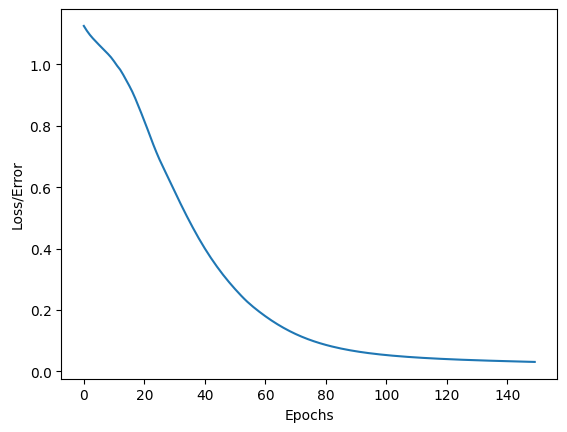

In [88]:
plt.plot(range(epochs), [loss.item() for loss in losses])
plt.ylabel('Loss/Error')
plt.xlabel('Epochs');

Evaluate Test Data on Trained Network/Model

In [89]:
with torch.no_grad(): ### Turns off back propogation
  y_eval = model.forward(X_test) ### Get predictions for test feature values
  loss = criterion(y_eval, y_test) ### Calculate loss error

loss

### We may want to evaluate this number agants the losses we obtained above.
### Around epoch 150, the loss is closer to 0.03
### Compared to that this is somewhat larger.

tensor(0.1332)

In [94]:
len(y_test)

30

In [90]:
### Let's evaluate how the predictions are diffferent from true values (test data)

correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    ### This will tell us what type of flower class out network think it is
    print(f'{i+1}.) {str(y_val)}')

  ### Note: We have 3 columns for 3 classes. The column with the highest number is the corresponding class.

1.) tensor([-6.8604,  4.7464,  7.6692])
2.) tensor([-8.8358,  3.6727, 12.1556])
3.) tensor([-9.9072,  4.8788, 12.6108])
4.) tensor([-5.0473,  7.0555,  2.0779])
5.) tensor([-8.4233,  4.9096, 10.0999])
6.) tensor([-3.7449,  6.2176,  0.7234])
7.) tensor([-6.9435,  5.5172,  6.9513])
8.) tensor([-4.9913,  7.1507,  1.8686])
9.) tensor([-7.6676,  5.2079,  8.5077])
10.) tensor([-9.4403,  3.8758, 12.9474])
11.) tensor([-6.6576,  5.5452,  6.4533])
12.) tensor([ 6.5207, -3.9181, -5.2197])
13.) tensor([ 6.0236, -3.4995, -4.8093])
14.) tensor([-2.2260e+00,  4.6107e+00, -3.4131e-03])
15.) tensor([ 4.9732, -2.4099, -4.3254])
16.) tensor([-6.3978,  5.9106,  5.6281])
17.) tensor([ 5.7966, -3.2543, -4.7462])
18.) tensor([-6.7901,  4.9821,  7.3040])
19.) tensor([ 6.3231, -3.7510, -5.0593])
20.) tensor([ 4.8863, -2.3985, -4.1618])
21.) tensor([-2.8104,  5.2290,  0.2752])
22.) tensor([-9.0848,  4.4888, 11.6702])
23.) tensor([ 5.1062, -2.5427, -4.4007])
24.) tensor([ 6.4349, -3.8668, -5.1005])
25.) tensor([

In [91]:
correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    ### This will tell us what type of flower class out network think it is
    print(f'{i+1}.) {str(y_val)}\t {y_test[i]}')

    ### See whether the  prediction is correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1

  print(f'We got {correct} correct!')


1.) tensor([-6.8604,  4.7464,  7.6692])	 2
2.) tensor([-8.8358,  3.6727, 12.1556])	 2
3.) tensor([-9.9072,  4.8788, 12.6108])	 2
4.) tensor([-5.0473,  7.0555,  2.0779])	 1
5.) tensor([-8.4233,  4.9096, 10.0999])	 2
6.) tensor([-3.7449,  6.2176,  0.7234])	 1
7.) tensor([-6.9435,  5.5172,  6.9513])	 2
8.) tensor([-4.9913,  7.1507,  1.8686])	 1
9.) tensor([-7.6676,  5.2079,  8.5077])	 2
10.) tensor([-9.4403,  3.8758, 12.9474])	 2
11.) tensor([-6.6576,  5.5452,  6.4533])	 2
12.) tensor([ 6.5207, -3.9181, -5.2197])	 0
13.) tensor([ 6.0236, -3.4995, -4.8093])	 0
14.) tensor([-2.2260e+00,  4.6107e+00, -3.4131e-03])	 1
15.) tensor([ 4.9732, -2.4099, -4.3254])	 0
16.) tensor([-6.3978,  5.9106,  5.6281])	 2
17.) tensor([ 5.7966, -3.2543, -4.7462])	 0
18.) tensor([-6.7901,  4.9821,  7.3040])	 1
19.) tensor([ 6.3231, -3.7510, -5.0593])	 0
20.) tensor([ 4.8863, -2.3985, -4.1618])	 0
21.) tensor([-2.8104,  5.2290,  0.2752])	 1
22.) tensor([-9.0848,  4.4888, 11.6702])	 2
23.) tensor([ 5.1062, -2.5427

In [93]:
correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    ### This will tell us what type of flower class out network think it is
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    ### See whether the  prediction is correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1

  print(f'We got {correct} correct!')

1.) tensor([-6.8604,  4.7464,  7.6692]) 	 2 	 2
2.) tensor([-8.8358,  3.6727, 12.1556]) 	 2 	 2
3.) tensor([-9.9072,  4.8788, 12.6108]) 	 2 	 2
4.) tensor([-5.0473,  7.0555,  2.0779]) 	 1 	 1
5.) tensor([-8.4233,  4.9096, 10.0999]) 	 2 	 2
6.) tensor([-3.7449,  6.2176,  0.7234]) 	 1 	 1
7.) tensor([-6.9435,  5.5172,  6.9513]) 	 2 	 2
8.) tensor([-4.9913,  7.1507,  1.8686]) 	 1 	 1
9.) tensor([-7.6676,  5.2079,  8.5077]) 	 2 	 2
10.) tensor([-9.4403,  3.8758, 12.9474]) 	 2 	 2
11.) tensor([-6.6576,  5.5452,  6.4533]) 	 2 	 2
12.) tensor([ 6.5207, -3.9181, -5.2197]) 	 0 	 0
13.) tensor([ 6.0236, -3.4995, -4.8093]) 	 0 	 0
14.) tensor([-2.2260e+00,  4.6107e+00, -3.4131e-03]) 	 1 	 1
15.) tensor([ 4.9732, -2.4099, -4.3254]) 	 0 	 0
16.) tensor([-6.3978,  5.9106,  5.6281]) 	 2 	 1
17.) tensor([ 5.7966, -3.2543, -4.7462]) 	 0 	 0
18.) tensor([-6.7901,  4.9821,  7.3040]) 	 1 	 2
19.) tensor([ 6.3231, -3.7510, -5.0593]) 	 0 	 0
20.) tensor([ 4.8863, -2.3985, -4.1618]) 	 0 	 0
21.) tensor([-2.8

Evaluate New Data on the Network